In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install node2vec tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 58.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requi

In [ ]:
 !pip uninstall -y jax numpy
 !pip cache purge

Found existing installation: jax 0.5.3
Uninstalling jax-0.5.3:
  Successfully uninstalled jax-0.5.3
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Files removed: 24


In [ ]:
 !pip install numpy==1.23.5
 !pip install --upgrade jax jaxlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 124.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orbax-checkpoint 0.11.21 requires jax>=0.5.0, which is not installed.
optax 0.2.5 requires jax>=0.4.27, which is not installed.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
flax 0.10.6 requires jax>=0.5.1, which is not installed.
chex 0.1.90 requires jax>=0.4.27, which is not installed.
node2vec 0.5.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 1.23.5 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
treescope 0.1.10 requires numpy>=1.25.2, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
pymc 5.25.1 requires numpy>=1.25.0, but you have numpy 1.23.5 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 MB 12.9 MB/s eta 0:00:00
   ━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/16.8 MB 165.5 MB/s eta 0:00:01
ERROR: Operation cancelled by user
^C


In [ ]:
import pandas as pd
from tqdm import tqdm
import json
import os
import random
import math
import pickle
import numpy as np
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, confusion_matrix
from collections import deque

import networkx as nx
import warnings
import keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import activations, initializers, constraints, regularizers
from tensorflow.keras.layers import Input, Layer, Lambda, Dropout, Reshape, Dense, Embedding, LeakyReLU, Maximum
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras import layers, optimizers, losses, metrics, Model
import matplotlib.pyplot as plt
import seaborn as sns

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass


In [ ]:
dataFrame = pd.read_csv("/content/drive/MyDrive/Journal/citation_sentiment_corpus.txt", sep = "	", header = None)
dataFrame.columns = ["Source_PaperID", "Target_PaperID", "Sentiment", "Citation_text"]
dataFrame.Sentiment = dataFrame.Sentiment.replace({"o": 1,"p": 2,"n": 0})

/tmp/ipython-input-2858447318.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataFrame.Sentiment = dataFrame.Sentiment.replace({"o": 1,"p": 2,"n": 0})


In [ ]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8736 entries, 0 to 8735
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Source_PaperID  8736 non-null   object
 1   Target_PaperID  8736 non-null   object
 2   Sentiment       8736 non-null   int64 
 3   Citation_text   8736 non-null   object
dtypes: int64(1), object(3)
memory usage: 273.1+ KB


In [ ]:
Source = dataFrame['Source_PaperID']
Target = dataFrame['Target_PaperID']
Sentiment = dataFrame['Sentiment']

In [ ]:
import math

def directed_preferential_attachment(graph, edges):
    """
    Preferential Attachment for directed graphs:
    PA(u, v) = out_degree(u) * in_degree(v)
    """
    scores = []
    for u, v in edges:
        score = graph.out_degree(u) * graph.in_degree(v)
        scores.append((u, v, score))
    return scores


def directed_resource_allocation_index(graph, edges):
    """
    Resource Allocation Index for directed graphs:
    Use common nodes that are successors of u and predecessors of v.
    RA(u, v) = sum over w ∈ Γ_out(u) ∩ Γ_in(v) of 1 / degree(w)
    """
    scores = []
    for u, v in edges:
        common_neighbors = set(graph.successors(u)).intersection(set(graph.predecessors(v)))
        score = sum(1 / graph.degree(w) for w in common_neighbors if graph.degree(w) > 0)
        scores.append((u, v, score))
    return scores


def directed_jaccard_coefficient(graph, edges):
    """
    Jaccard Coefficient for directed graphs:
    JC(u, v) = |Γ_out(u) ∩ Γ_in(v)| / |Γ_out(u) ∪ Γ_in(v)|
    """
    scores = []
    for u, v in edges:
        succ_u = set(graph.successors(u))     # out-neighbors of u
        pred_v = set(graph.predecessors(v))   # in-neighbors of v
        intersection = succ_u & pred_v
        union = succ_u | pred_v
        score = len(intersection) / len(union) if union else 0
        scores.append((u, v, score))
    return scores


def directed_adamic_adar_index(graph, edges):
    """
    Adamic-Adar Index for directed graphs:
    AA(u, v) = sum over w ∈ Γ_out(u) ∩ Γ_in(v) of 1 / log(degree(w))
    """
    scores = []
    for u, v in edges:
        succ_u = set(graph.successors(u))     # out-neighbors of u
        pred_v = set(graph.predecessors(v))   # in-neighbors of v
        common_neighbors = succ_u & pred_v
        score = sum(1 / math.log(graph.degree(w)) for w in common_neighbors if graph.degree(w) > 1)
        scores.append((u, v, score))
    return scores


In [ ]:
import networkx as nx
import pandas as pd

edges = pd.DataFrame({
    "source": Source,
    "target": Target,
    "weight": [1] * len(Source)  # or use real weights if available
})

# Build a directed graph from the DataFrame
G = nx.from_pandas_edgelist(
    edges,
    source='source',
    target='target',
    edge_attr=True,  # includes all other columns (like 'weight') as edge attributes
    create_using=nx.DiGraph()
)


In [ ]:
# Create a leaderboard for nodes based on their degree (number of connections)
leaderboard = {node: G.degree(node) for node in G.nodes()}

# Convert the leaderboard to a pandas Series and then to a DataFrame
s = pd.Series(leaderboard, name="Citations")
citation_counts = s.to_frame().sort_values("Citations", ascending=False)

# Display the count of unique citation values
citation_value_counts = citation_counts.value_counts()

# Display results
print("Citation Counts:")
print(citation_counts.head())  # Top-ranked nodes by citations
print("\nValue Counts of Citations:")
print(citation_value_counts)


Citation Counts:
          Citations
J93-2004        436
J93-2003        368
P02-1040        305
P03-1021        281
N03-1017        240

Value Counts of Citations:
Citations
1            1755
2             684
3             283
4             129
5              77
6              26
7              14
8              13
9              11
10              7
11              5
15              4
17              4
20              4
14              4
22              3
13              2
18              2
71              2
27              2
30              2
12              2
151             1
101             1
109             1
117             1
121             1
125             1
138             1
172             1
152             1
368             1
182             1
212             1
240             1
281             1
305             1
95              1
31              1
67              1
29              1
16              1
19              1
23              1
24              1
25             

In [ ]:
print("Number of Nodes: ",G.number_of_nodes())
print("Number of Edges: ",G.number_of_edges())

Number of Nodes:  3069
Number of Edges:  5042


In [ ]:
#!pip install node2vec

In [ ]:
df=dataFrame
import pandas as pd
import numpy as np
from node2vec import Node2Vec
import tensorflow_hub as hub
import tensorflow as tf


In [ ]:
leaderboard = {}
for x in G.nodes:
 leaderboard[x] = len(G[x])
s = pd.Series(leaderboard, name='Citations')
citation_counts = s.to_frame().sort_values('Citations', ascending=False)
citation_counts.value_counts()

,count
Citations,
1,1785
2,703
3,295
4,121
0,77
5,59
6,19
7,7
8,3


In [ ]:
citation_counts = citation_counts.reset_index(level=0)
citation_counts.columns = ['Node', 'Citations']
citation_counts.head()

,Node,Citations
0,W08-0306,8
1,N09-1058,8
2,D07-1070,8
3,N09-1049,7
4,P08-1068,7


In [ ]:
print("Number of Nodes: ",G.number_of_nodes())
print("Number of Edges: ",G.number_of_edges())

Number of Nodes:  3069
Number of Edges:  5042


In [ ]:
zero_list = []
for i,j in zip(citation_counts['Node'], citation_counts['Citations']):
    if(j == 0):

        zero_list.append(i)
G.remove_nodes_from(zero_list)

In [ ]:

# ----- NODE-LEVEL FEATURES -----

# In-degree, Out-degree, Total Degree Centrality
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# Betweenness, Closeness, Eigenvector Centrality
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)

# Combine Node Features into a DataFrame
node_features = pd.DataFrame({
    "node": list(G.nodes()),
    "in_degree": [in_degrees[node] for node in G.nodes()],
    "out_degree": [out_degrees[node] for node in G.nodes()],
    "total_degree": [total_degrees[node] for node in G.nodes()],
    "betweenness": [betweenness[node] for node in G.nodes()],
    "closeness": [closeness[node] for node in G.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[node] for node in G.nodes()],
})


# ----- EDGE-LEVEL FEATURES USING CUSTOM FUNCTIONS -----
# Preferential Attachment
pref_attach = directed_preferential_attachment(G, G.edges())

# Resource Allocation Index
resource_allocation_scores = directed_resource_allocation_index(G, G.edges())

# Jaccard Coefficient
jaccard_scores = directed_jaccard_coefficient(G, G.edges())

# Adamic-Adar Index
adamic_adar_scores = directed_adamic_adar_index(G, G.edges())

# Combine Edge Features into a DataFrame
edge_features = pd.DataFrame({
    "source": [u for u, v, _ in pref_attach],
    "target": [v for u, v, _ in pref_attach],
    "preferential_attachment": [score for _, _, score in pref_attach],
    "resource_allocation": [score for _, _, score in resource_allocation_scores],
    "jaccard": [score for _, _, score in jaccard_scores],
    "adamic_adar": [score for _, _, score in adamic_adar_scores],
})



In [ ]:
print(edge_features.describe())

       preferential_attachment  resource_allocation      jaccard  adamic_adar
count              1589.000000          1589.000000  1589.000000  1589.000000
mean                141.224670             0.011998     0.002853     0.053190
std                 177.346121             0.050893     0.015371     0.179574
min                   1.000000             0.000000     0.000000     0.000000
25%                  20.000000             0.000000     0.000000     0.000000
50%                  68.000000             0.000000     0.000000     0.000000
75%                 169.000000             0.000000     0.000000     0.000000
max                1185.000000             0.666667     0.250000     1.820478


In [ ]:
#further Improvement and Normalization

path_lengths = []
for u, v in G.edges():
    try:
        path_length = nx.shortest_path_length(G, u, v)
    except nx.NetworkXNoPath:
        path_length = -1  # or a high value
    path_lengths.append(path_length)

edge_features["shortest_path_length"] = path_lengths


In [ ]:
node_features.shape , edge_features.shape

((2992, 7), (1589, 7))

In [ ]:
node_features.columns, edge_features.columns

(Index(['node', 'in_degree', 'out_degree', 'total_degree', 'betweenness',
        'closeness', 'eigenvector_centrality'],
       dtype='object'),
 Index(['source', 'target', 'preferential_attachment', 'resource_allocation',
        'jaccard', 'adamic_adar', 'shortest_path_length'],
       dtype='object'))

In [ ]:
print("Number of Nodes: ",G.number_of_nodes())
print("Number of Edges: ",G.number_of_edges())

Number of Nodes:  2992
Number of Edges:  1589


In [ ]:
# ----- STEP 2: NODE2VEC EMBEDDINGS -----
node2vec = Node2Vec(G, dimensions=128, walk_length=80, num_walks=10, workers=4)
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Create a DataFrame for Node2Vec embeddings
node2vec_embeddings = pd.DataFrame(
    [node2vec_model.wv[str(node)] for node in G.nodes()],
    index=[str(node) for node in G.nodes()],
    columns=[f"node2vec_dim_{i}" for i in range(128)]
)


Computing transition probabilities:   0%|          | 0/2992 [00:00<?, ?it/s]

In [ ]:
node2vec_embeddings.head()

,node2vec_dim_0,node2vec_dim_1,node2vec_dim_2,node2vec_dim_3,node2vec_dim_4,node2vec_dim_5,node2vec_dim_6,node2vec_dim_7,node2vec_dim_8,node2vec_dim_9,...,node2vec_dim_118,node2vec_dim_119,node2vec_dim_120,node2vec_dim_121,node2vec_dim_122,node2vec_dim_123,node2vec_dim_124,node2vec_dim_125,node2vec_dim_126,node2vec_dim_127
A00-1043,-0.004032,-0.003772,-0.006619,0.000295,0.001475,0.002684,-0.007289,-0.003288,0.007746,-0.002070,...,0.007749,-0.000912,0.003677,-4.483217e-03,-0.006047,-0.001022,0.004531,-0.003030,-0.002101,0.001347
H05-1033,-0.001480,-0.007540,0.001580,-0.000120,0.007079,-0.003769,0.000354,0.004946,0.005107,-0.001600,...,0.004311,0.000760,0.001778,-1.237509e-03,0.003153,0.005554,0.001201,-0.004602,-0.005909,-0.003485
I05-2009,0.002274,-0.002724,-0.001452,-0.004859,-0.006899,0.005863,0.005546,0.005919,0.005519,-0.005195,...,0.007760,0.004712,-0.001209,-1.603656e-03,0.005203,0.001152,0.005537,0.006025,0.001856,0.003811
I08-1016,0.001360,-0.005649,-0.000393,-0.005364,0.000293,-0.005754,-0.003876,-0.002239,0.001630,-0.002090,...,0.002120,-0.001543,0.002821,-3.665077e-03,0.004337,0.002539,0.004781,-0.001409,-0.006031,0.004477
I08-2101,0.007777,-0.007083,0.000251,0.006919,0.007128,0.006570,0.005534,0.001042,-0.000810,0.005606,...,0.003969,-0.002883,-0.002019,-4.312024e-07,-0.002726,-0.003376,-0.004697,0.005775,0.005022,0.006282


In [ ]:
# Ensure Node2Vec embeddings cover all nodes in the original DataFrame
all_nodes = df["Source_PaperID"].unique()
missing_nodes = set(all_nodes) - set(node2vec_embeddings.index)
for node in missing_nodes:
    node2vec_embeddings.loc[node] = np.zeros(128)

In [ ]:
# Reindex to ensure the order matches `all_nodes`
node2vec_embeddings = node2vec_embeddings.reindex(all_nodes)

In [ ]:
node2vec_embeddings.shape

(2992, 128)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import tensorflow_hub as hub
import tensorflow as tf

# Node2Vec embeddings with `Source_PaperID` as the index
node2vec_embeddings.index.name = "Source_PaperID"

In [ ]:

# ----- STEP 2: EXTRACT CITATION TEXTS FOR UNIQUE NODES -----
# Select only rows where `Source_PaperID` matches `node2vec_embeddings` index
citation_texts = df[df["Source_PaperID"].isin(node2vec_embeddings.index)]
citation_texts.shape

(8736, 4)

In [ ]:
# Ensure unique rows for `Source_PaperID` (if duplicates exist, group by and take the first)
unique_citation_texts = citation_texts.groupby("Source_PaperID").first().reset_index()

In [ ]:
unique_citation_texts.shape

(2992, 4)

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from tqdm import tqdm

# ----- STEP 1: LOAD BERT ON CUDA -----
bert_model_name = "bert-base-uncased"  # Change to any BERT variant you prefer
tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name).to("cuda")  # Move model to GPU

# Function to compute BERT embeddings for texts
def compute_bert_embeddings(texts):
    embeddings = []
    for text in tqdm(texts, desc="Processing BERT embeddings"):
        # Tokenize and encode text
        inputs = tokenizer(
            text, return_tensors="pt", truncation=True, padding="max_length", max_length=512
        ).to("cuda")  # Move inputs to GPU

        # Forward pass through the BERT model
        with torch.no_grad():
            outputs = bert_model(**inputs)

        # Use the [CLS] token embedding as the sentence representation
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
        embeddings.append(cls_embedding)
    return np.array(embeddings)

# Ensure unique rows for `Source_PaperID`
unique_citation_texts = citation_texts.groupby("Source_PaperID").first().reset_index()

# Extract citation texts and their corresponding `Source_PaperID`
texts_to_encode = unique_citation_texts["Citation_text"].tolist()
source_ids = unique_citation_texts["Source_PaperID"].tolist()

# ----- STEP 3: COMPUTE BERT EMBEDDINGS -----
bert_embeddings = compute_bert_embeddings(texts_to_encode)

# Reduce BERT embeddings to 128 dimensions using PCA
pca = PCA(n_components=128)
reduced_bert_embeddings = pca.fit_transform(bert_embeddings)

# Create a DataFrame for reduced BERT embeddings
bert_embeddings_df = pd.DataFrame(
    reduced_bert_embeddings,
    index=source_ids,  # Use `Source_PaperID` as the index
    columns=[f"bert_dim_{i}" for i in range(128)]
)

# ----- STEP 4: MERGE NODE2VEC AND BERT -----
# Concatenate Node2Vec and reduced BERT embeddings
combined_embeddings = bert_embeddings_df

# ----- STEP 5: ADD SENTIMENT LABELS -----
# Map sentiment labels from the original DataFrame
sentiment_dict = df.set_index("Source_PaperID")["Sentiment"].to_dict()
combined_embeddings["sentiment"] = combined_embeddings.index.map(sentiment_dict)

# ----- STEP 6: FINAL DATAFRAME -----
# Reset index for final output
final_df = combined_embeddings.reset_index()

# Final DataFrame includes:
# - `Source_PaperID`: Node ID.
# - `node2vec_dim_*`: Node2Vec embeddings (128 dimensions).
# - `bert_dim_*`: BERT embeddings (128 dimensions).
# - `sentiment`: Sentiment label (target value).
print(final_df.head())
print("\nShape of the final DataFrame:", final_df.shape)


Processing BERT embeddings: 100%|██████████| 2992/2992 [01:43<00:00, 28.87it/s]


      index  bert_dim_0  bert_dim_1  bert_dim_2  bert_dim_3  bert_dim_4  \
0  A00-1004   -1.416996    3.080554    0.883337    0.436423    0.312903   
1  A00-1005   -1.938545    2.263874    0.381174    0.042243   -1.363877   
2  A00-1007    0.091383   -2.042176    3.897648    1.959153   -0.314123   
3  A00-1011   -0.618923   -1.249521   -0.298868   -1.988906   -1.755697   
4  A00-1012    0.032316    0.348407    0.054117    1.618249   -0.744866   

   bert_dim_5  bert_dim_6  bert_dim_7  bert_dim_8  ...  bert_dim_119  \
0   -0.342480    0.280378    0.529429    0.012927  ...     -0.014111   
1   -0.678144   -0.588817    1.265440    0.315046  ...     -0.032764   
2    1.525755    0.285060   -0.331656    0.313628  ...     -0.068082   
3   -0.538416    0.358814   -1.728714    0.044989  ...      0.079206   
4    0.196870    0.720971   -0.390185    1.085734  ...      0.005526   

   bert_dim_120  bert_dim_121  bert_dim_122  bert_dim_123  bert_dim_124  \
0      0.005963     -0.010771      0.1758

In [ ]:
final_df.head()

,index,bert_dim_0,bert_dim_1,bert_dim_2,bert_dim_3,bert_dim_4,bert_dim_5,bert_dim_6,bert_dim_7,bert_dim_8,...,bert_dim_119,bert_dim_120,bert_dim_121,bert_dim_122,bert_dim_123,bert_dim_124,bert_dim_125,bert_dim_126,bert_dim_127,sentiment
0,A00-1004,-1.416996,3.080554,0.883337,0.436423,0.312903,-0.342480,0.280378,0.529429,0.012927,...,-0.014111,0.005963,-0.010771,0.175844,-0.182294,-0.168251,-0.098709,0.106996,0.118119,1
1,A00-1005,-1.938545,2.263874,0.381174,0.042243,-1.363877,-0.678144,-0.588817,1.265440,0.315046,...,-0.032764,0.339523,-0.104740,-0.247963,-0.267406,-0.105029,-0.084752,0.044819,0.191899,2
2,A00-1007,0.091383,-2.042176,3.897648,1.959153,-0.314123,1.525755,0.285060,-0.331656,0.313628,...,-0.068082,0.222807,-0.174709,-0.115459,-0.353255,-0.490331,-0.132950,-0.431731,-0.392567,1
3,A00-1011,-0.618923,-1.249521,-0.298868,-1.988906,-1.755697,-0.538416,0.358814,-1.728714,0.044989,...,0.079206,-0.461830,0.308581,-0.034285,-0.394636,0.327226,-0.397651,0.220092,0.091272,1
4,A00-1012,0.032316,0.348407,0.054117,1.618249,-0.744866,0.196870,0.720971,-0.390185,1.085734,...,0.005526,0.227314,0.000670,0.009874,0.156247,-0.423316,-0.218683,0.173552,0.033033,1


In [ ]:
dataset = final_df

In [ ]:
dataset.rename(columns={"Source_PaperID": "Node_id"}, inplace=True)
dataset.rename(columns={"sentiment": "label"}, inplace=True)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2992 entries, 0 to 2991
Columns: 130 entries, index to label
dtypes: float32(128), int64(1), object(1)
memory usage: 1.5+ MB


In [ ]:
node2vec_cc = dataset

In [ ]:
graph = nx.to_pandas_edgelist(G)

graph

,source,target,weight
0,W09-0604,N03-1003,1
1,A00-1031,W96-0213,1
2,A97-1004,W96-0213,1
3,C08-1026,P08-1085,1
4,N01-1023,W96-0213,1
...,...,...,...
1584,W07-1209,W96-0213,1
1585,W07-1516,W96-0213,1
1586,W07-2053,W96-0213,1
1587,W08-0611,W96-0213,1


In [ ]:
node2vec_cc["Node_id"] = dataset["index"]
node2vec_cc["label"] = dataset["label"]

In [ ]:
node2vec_cc.drop(columns = ["index"], inplace = True)

In [ ]:
paper_idx = {name: idx for idx, name in enumerate(node2vec_cc["Node_id"])}

node2vec_cc["Node_id"] = node2vec_cc["Node_id"].apply(lambda name: paper_idx[name])
graph["source"] = graph["source"].apply(lambda name: paper_idx[name])
graph["target"] = graph["target"].apply(lambda name: paper_idx[name])

In [ ]:
node2vec_cc.columns

Index(['bert_dim_0', 'bert_dim_1', 'bert_dim_2', 'bert_dim_3', 'bert_dim_4',
       'bert_dim_5', 'bert_dim_6', 'bert_dim_7', 'bert_dim_8', 'bert_dim_9',
       ...
       'bert_dim_120', 'bert_dim_121', 'bert_dim_122', 'bert_dim_123',
       'bert_dim_124', 'bert_dim_125', 'bert_dim_126', 'bert_dim_127', 'label',
       'Node_id'],
      dtype='object', length=130)

In [ ]:
node2vec_cc.head()

,bert_dim_0,bert_dim_1,bert_dim_2,bert_dim_3,bert_dim_4,bert_dim_5,bert_dim_6,bert_dim_7,bert_dim_8,bert_dim_9,...,bert_dim_120,bert_dim_121,bert_dim_122,bert_dim_123,bert_dim_124,bert_dim_125,bert_dim_126,bert_dim_127,label,Node_id
0,-1.416996,3.080554,0.883337,0.436423,0.312903,-0.342480,0.280378,0.529429,0.012927,-0.416564,...,0.005963,-0.010771,0.175844,-0.182294,-0.168251,-0.098709,0.106996,0.118119,1,0
1,-1.938545,2.263874,0.381174,0.042243,-1.363877,-0.678144,-0.588817,1.265440,0.315046,0.491042,...,0.339523,-0.104740,-0.247963,-0.267406,-0.105029,-0.084752,0.044819,0.191899,2,1
2,0.091383,-2.042176,3.897648,1.959153,-0.314123,1.525755,0.285060,-0.331656,0.313628,0.977599,...,0.222807,-0.174709,-0.115459,-0.353255,-0.490331,-0.132950,-0.431731,-0.392567,1,2
3,-0.618923,-1.249521,-0.298868,-1.988906,-1.755697,-0.538416,0.358814,-1.728714,0.044989,0.667782,...,-0.461830,0.308581,-0.034285,-0.394636,0.327226,-0.397651,0.220092,0.091272,1,3
4,0.032316,0.348407,0.054117,1.618249,-0.744866,0.196870,0.720971,-0.390185,1.085734,-0.694198,...,0.227314,0.000670,0.009874,0.156247,-0.423316,-0.218683,0.173552,0.033033,1,4


In [ ]:
df=node2vec_cc

In [ ]:
train_label_cc, test_pages = train_test_split(node2vec_cc['label'], test_size = 0.30)
val_label_cc, test_label_cc = train_test_split(test_pages, test_size=0.40)

In [ ]:
train_Node2Vec_cc = node2vec_cc.loc[train_label_cc.index]
val_Node2Vec_cc = node2vec_cc.loc[val_label_cc.index]
test_Node2Vec_cc = node2vec_cc.loc[test_label_cc.index]

In [ ]:
train_Node2Vec_cc.head()

,bert_dim_0,bert_dim_1,bert_dim_2,bert_dim_3,bert_dim_4,bert_dim_5,bert_dim_6,bert_dim_7,bert_dim_8,bert_dim_9,...,bert_dim_120,bert_dim_121,bert_dim_122,bert_dim_123,bert_dim_124,bert_dim_125,bert_dim_126,bert_dim_127,label,Node_id
1799,-2.158726,0.248539,0.976167,-0.938543,-0.059331,0.935047,-0.345293,-1.048487,-2.619501,-0.517279,...,0.031678,-0.394735,-0.199605,0.219274,-0.267909,0.553120,0.120842,0.027271,1,1799
803,0.856790,-2.528100,2.141310,-0.614037,1.387434,-1.324359,-1.319406,-1.761218,0.252850,-2.606099,...,-0.090213,0.236326,-0.274206,0.219785,0.001270,0.055019,-0.327376,0.265844,1,803
2163,1.088467,0.073898,-1.803473,0.802947,1.457537,1.705384,0.389634,-0.230816,-0.185903,-0.761136,...,0.142920,-0.059932,0.226251,0.028545,0.244725,0.044401,0.064942,-0.157781,1,2163
1650,-1.632698,-0.825039,-0.991843,0.551771,0.426770,1.248937,-0.327148,2.038072,-0.051091,-1.387810,...,0.001463,0.043284,0.047639,-0.073485,0.050711,0.106074,-0.167177,0.009159,1,1650
2763,4.520274,-3.940804,3.610435,-4.984165,2.033597,-0.586276,0.951217,0.237999,0.266118,0.678960,...,-0.142467,-0.407050,-0.043290,-0.347763,0.127258,0.443204,-0.223180,0.191436,1,2763


In [ ]:
train_Node2Vec_cc.shape, val_Node2Vec_cc.shape, test_Node2Vec_cc.shape

((2094, 130), (538, 130), (360, 130))

In [ ]:
test_Node2Vec_cc

,bert_dim_0,bert_dim_1,bert_dim_2,bert_dim_3,bert_dim_4,bert_dim_5,bert_dim_6,bert_dim_7,bert_dim_8,bert_dim_9,...,bert_dim_120,bert_dim_121,bert_dim_122,bert_dim_123,bert_dim_124,bert_dim_125,bert_dim_126,bert_dim_127,label,Node_id
2382,-1.509042,1.031416,-1.266769,2.099825,-0.523215,0.249711,-0.388195,-0.535265,-1.428779,-0.970658,...,-0.076531,0.062967,0.094345,-0.248932,-0.032640,-0.077262,0.066378,0.057670,1,2382
1369,2.227947,1.103265,-0.089386,0.854277,-1.455087,-0.547832,0.721472,0.396534,-0.062404,-0.116393,...,-0.177789,-0.018317,-0.252058,0.002816,-0.098688,-0.218111,0.180693,0.085891,1,1369
2739,-2.908324,2.515828,1.290140,0.524434,0.446087,-0.266574,-0.415256,-0.393541,-0.172214,-0.622708,...,0.020837,0.033660,-0.032352,0.073255,-0.001494,0.003251,0.085712,-0.155899,2,2739
1688,-3.271736,-0.953836,1.238683,0.895270,1.219690,1.444778,2.237060,-0.250812,-1.447016,0.462228,...,0.455800,0.182695,-0.279311,-0.000093,-0.025492,-0.205838,0.431518,0.142516,1,1688
1206,-2.021922,0.082363,0.502184,0.131473,-0.591386,-0.752685,2.075308,0.561192,-1.271958,-0.012979,...,-0.045787,-0.039026,0.139703,0.117113,0.043159,-0.261911,-0.040505,0.077166,1,1206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2872,-1.221036,-2.032271,1.797764,-2.860803,-1.510012,0.707983,0.091035,2.626404,1.078908,-1.008574,...,-0.220502,0.546743,0.034217,0.482765,0.113210,-0.322817,-0.196597,-0.110447,1,2872
2772,2.078013,-3.145504,-0.779049,2.849011,-2.587486,2.322233,-0.867168,0.845553,-0.563591,-0.275216,...,-0.340454,0.020818,0.151692,0.012591,-0.132920,-0.216263,0.038319,-0.471116,1,2772
675,1.887601,3.850073,1.291911,0.197889,0.698370,-0.180150,-0.462150,0.165881,-1.075632,-0.309138,...,-0.137674,0.007913,0.189374,-0.285260,-0.168876,-0.124059,0.292205,0.065674,1,675
43,-1.465439,1.177623,-0.191433,1.233713,-1.502996,-0.076795,1.066034,-0.252535,-0.579294,-1.241716,...,0.042858,0.273568,0.155451,-0.125657,0.037515,0.059929,-0.138151,-0.058600,2,43


In [ ]:
y_train = np.array(list(train_label_cc.values))
y_val = np.array(list(val_label_cc.values))
y_test = np.array(list(test_label_cc.values))

In [ ]:
y_train

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
graph.head()

,source,target,weight
0,2779,985,1
1,10,2887,1
2,38,2887,1
3,201,1697,1
4,982,2887,1


In [ ]:
# Extract column names excluding 'Node_id' and 'label'
column_names = [col for col in node2vec_cc.columns if col not in ['Node_id', 'label']]

# Print out the column names
print("Columns excluding 'Node_id' and 'label':", len(column_names))

Columns excluding 'Node_id' and 'label': 128


In [ ]:
# Create an edges array (sparse adjacency matrix) of shape [2, num_edges].
edges = graph[["source", "target"]].to_numpy().T


edge_weights = tf.ones(shape=edges.shape[1],dtype = tf.dtypes.float32)
# Create a node features array of shape [num_nodes, num_features].
node_features = tf.cast(
    node2vec_cc.sort_values('Node_id')[column_names].apply(pd.to_numeric).to_numpy(), dtype=tf.dtypes.float32
)
# Create graph info tuple with node_features, edges, and edge_weights.
graph_info = (node_features, edges, edge_weights)

print("Edges shape:", edges.shape)
print("Nodes shape:", node_features.shape)

Edges shape: (2, 1589)
Nodes shape: (2992, 128)


In [ ]:
kernel_initializer="glorot_uniform"
bias = True
bias_initializer="zeros"
n_layers = 2
layer_sizes = [32, 32]
dropout = 0.5
kernel_regularizer='l2'

hidden_units = [128,64]
learning_rate = 0.01
dropout_rate = 0.5
num_epochs = 300
batch_size = 256
bias_regularizer = "l2"

In [ ]:
class BatchNormalization(keras.layers.Layer):

  def build(self, input_shape):
    # print("Batch Input Shape:", input_shape)
    dim = input_shape[-1]
    self.gamma = self.add_weight(shape=(dim,),
                                 initializer=keras.initializers.ones,
                                 trainable=True)
    self.beta = self.add_weight(shape=(dim,),
                                initializer=keras.initializers.zeros,
                                trainable=True)
    self.var = self.add_weight(shape=(dim,),
                               initializer=keras.initializers.ones,
                               trainable=False)
    self.mean = self.add_weight(shape=(dim,),
                                initializer=keras.initializers.zeros,
                                trainable=False)

  def call(self, inputs, training=None):
    if training:
      mean, var = tf.nn.moments(inputs,
                                axes=[i for i in range(inputs.shape.rank - 1)])
      normalized = (inputs - mean) / var
      self.var.assign(self.var * 0.9 + var * 0.1)
      self.mean.assign(self.mean * 0.9 + mean * 0.1)
    else:
      normalized = (inputs - self.mean) / self.var
    return normalized * self.gamma + self.beta


In [ ]:
import tensorflow as tf

# from .layers import Layer, Dense
# from .inits import glorot, zeros

class MeanAggregator(keras.layers.Layer):
    """
    Aggregates via mean followed by matmul and non-linearity.
    """

    def __init__(self,units,
            dropout=0., bias=False, act=tf.nn.relu,
            name=None, concat=False,**kwargs):
        super(MeanAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

    def get_config(self):
        config = super(MeanAggregator, self).get_config()
        config.update({"units": self.units, "dropout":self.dropout, "bias":self.bias, "activation":self.act, "concat":self.concat})
        return config

    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(MeanAggregator, self).build(input_shape = input_shape)


    def call(self, inputs, training = None):
        self_vecs, neigh_vecs = inputs

        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs
        # neigh_vecs = tf.nn.dropout(neigh_vecs, 1-self.dropout)
        # self_vecs = tf.nn.dropout(self_vecs, 1-self.dropout)
        neigh_means = tf.math.unsorted_segment_mean(neighbour_messages, node_indices, num_segments=num_nodes)
        # print("Neighbour means:",neigh_means.shape)
        # [nodes] x [out_dim]
        from_neighs = tf.matmul(neigh_means, self.neigh_weights)

        from_self = tf.matmul(self_vecs, self.self_weights)

        if not self.concat:
            output = tf.add_n([from_self, from_neighs])
        else:
            output = tf.concat([from_self, from_neighs], axis=1)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)

class GCNAggregator(Layer):
    """
    Aggregates via mean followed by matmul and non-linearity.
    Same matmul parameters are used self vector and neighbor vectors.
    """

    def __init__(self, units,
            dropout=0., bias=False, act=tf.nn.relu, name=None, concat=False, **kwargs):
        super(GCNAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

    def build(self, input_shape):
        input_dim = input_shape[0][-1]
        initializer = tf.keras.initializers.GlorotNormal()
        self.W = tf.Variable(initial_value=initializer(shape = (2*input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
            zeros = tf.keras.initializers.zeros()
            self.bias_init= tf.Variable(initial_value=zeros(shape =(self.units),dtype='float32'),trainable=True)

        super(GCNAggregator, self).build(input_shape = input_shape)

    def call(self, inputs):
        self_vecs, neigh_vecs = inputs

        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs
        neigh_means = tf.math.unsorted_segment_mean(neighbour_messages, node_indices, num_segments=num_nodes)


        means = tf.concat([neigh_means,self_vecs], axis=1)

        # [nodes] x [out_dim]
        output = tf.matmul(means, self.W)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)


class MaxPoolingAggregator(Layer):
    """ Aggregates via max-pooling over MLP functions.
    """
    def __init__(self, units,
            dropout=0., bias=False, act=tf.nn.relu, name=None, concat=False, **kwargs):
        super(MaxPoolingAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

        hidden_dim = self.hidden_dim = 512
        self.mlp_layers = []
        self.mlp_layers.append(Dense(units=hidden_dim,
                                 activation=tf.nn.relu))

    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(self.hidden_dim, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(MaxPoolingAggregator, self).build(input_shape = input_shape)

    def call(self, inputs, training = None):
        self_vecs, neigh_vecs = inputs
        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs

        # [num_edges] x [hidden_dim]
        h_reshaped = neighbour_messages

        for l in self.mlp_layers:
            h_reshaped = l(h_reshaped)

        neighbour_messages = h_reshaped

        neigh_h = tf.math.unsorted_segment_max(neighbour_messages, node_indices, num_segments=num_nodes)

        from_neighs = tf.matmul(neigh_h, self.neigh_weights)
        from_self = tf.matmul(self_vecs, self.self_weights)

        if not self.concat:
            output = tf.add_n([from_self, from_neighs])
        else:
            output = tf.concat([from_self, from_neighs], axis=1)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)

class MeanPoolingAggregator(Layer):
    """ Aggregates via mean-pooling over MLP functions.
    """
    def __init__(self, units,
            dropout=0., bias=False, act=tf.nn.relu, name=None, concat=False, **kwargs):
        super(MeanPoolingAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

        hidden_dim = self.hidden_dim = 512

        self.mlp_layers = []
        self.mlp_layers.append(Dense(units=hidden_dim,
                                 activation=tf.nn.relu))


    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(self.hidden_dim, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(MeanPoolingAggregator, self).build(input_shape = input_shape)

    def call(self, inputs):
        self_vecs, neigh_vecs = inputs
        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs

        # [num_edges] x [hidden_dim]
        h_reshaped = neighbour_messages

        for l in self.mlp_layers:
            h_reshaped = l(h_reshaped)

        neighbour_messages = h_reshaped

        neigh_h = tf.math.unsorted_segment_mean(neighbour_messages, node_indices, num_segments=num_nodes)

        from_neighs = tf.matmul(neigh_h, self.neigh_weights)
        from_self = tf.matmul(self_vecs, self.self_weights)

        if not self.concat:
            output = tf.add_n([from_self, from_neighs])
        else:
            output = tf.concat([from_self, from_neighs], axis=1)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)


class TwoMaxLayerPoolingAggregator(Layer):
    """ Aggregates via pooling over two MLP functions.
    """
    def __init__(self, input_dim, output_dim, model_size="small", neigh_input_dim=None,
            dropout=0., bias=False, act=tf.nn.relu, name=None, concat=False, **kwargs):
        super(TwoMaxLayerPoolingAggregator, self).__init__(**kwargs)

        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat



        hidden_dim_1 = self.hidden_dim_1 = 512
        hidden_dim_2 = self.hidden_dim_2 = 256

        self.mlp_layers = []
        self.mlp_layers.append(Dense(units=hidden_dim_1,
                                 activation=tf.nn.relu))
        self.mlp_layers.append(Dense(units =hidden_dim_2,
                                 activation=tf.nn.relu))

    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(self.hidden_dim_2, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(TwoMaxLayerPoolingAggregator, self).build(input_shape = input_shape)

    def call(self, inputs, training = None):
        self_vecs, neigh_vecs = inputs
        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs

        # [num_edges] x [hidden_dim]
        h_reshaped = neighbour_messages

        for l in self.mlp_layers:
            h_reshaped = l(h_reshaped)

        neighbour_messages = h_reshaped

        neigh_h = tf.math.unsorted_segment_max(neighbour_messages, node_indices, num_segments=num_nodes)

        from_neighs = tf.matmul(neigh_h, self.neigh_weights)
        from_self = tf.matmul(self_vecs, self.self_weights)

        if not self.concat:
            output = tf.add_n([from_self, from_neighs])
        else:
            output = tf.concat([from_self, from_neighs], axis=1)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)

class SeqAggregator(Layer):
    """ Aggregates via a standard LSTM.
    """
    def __init__(self, units,
            dropout=0., bias=False, act=tf.nn.relu, name=None,  concat=False, **kwargs):
        super(SeqAggregator, self).__init__(**kwargs)
        self.units = units
        self.dropout = dropout
        self.bias = bias
        self.act = act
        self.concat = concat

        # hidden_dim = self.hidden_dim = 128


        # self.lstm = tf.keras.layers.LSTM(units = hidden_dim)
        self.gru = layers.GRU(
                units=self.units,
                activation="tanh",
                recurrent_activation="sigmoid",
                dropout=dropout_rate,
                # return_state=True,
                # recurrent_dropout=dropout_rate,
            )


    def build(self, input_shape):
        # print("Input shape:", input_shape[0][-1])
        input_dim = input_shape[0][-1]
        w_init = tf.random_normal_initializer()
        self.neigh_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'), trainable=True)
        self.self_weights = tf.Variable(initial_value=w_init(shape=(input_dim, self.units),dtype='float32'),trainable=True)
        if self.bias:
          b_init = tf.zeros_initializer()
          self.bias_init = tf.Variable(initial_value=b_init(shape=(self.units,), dtype='float32'),trainable=True)
        super(SeqAggregator, self).build(input_shape = input_shape)

    def call(self, inputs):
        self_vecs, neigh_vecs = inputs
        num_nodes = self_vecs.shape[0]
        node_indices, neighbour_messages = neigh_vecs

        neigh_h = tf.math.unsorted_segment_max(neighbour_messages, node_indices, num_segments=num_nodes)
        # Create a sequence of two elements for the GRU layer.
        #print(neigh_h)
        from_neighs = tf.matmul(neigh_h, self.neigh_weights)
        from_self = tf.matmul(self_vecs, self.self_weights)

        h = tf.stack([from_self, from_neighs], axis=1)

        output = self.gru(h)

        # bias
        if self.bias:
            output += self.bias_init

        return self.act(output)

In [ ]:
class GraphConvLayer(layers.Layer):
    def __init__(
        self,
        units,
        dropout_rate=0.2,
        aggregation_type="mean",
        normalize=False,
        *args,
        **kwargs,
    ):
        super(GraphConvLayer, self).__init__(*args, **kwargs)
        self.units = units
        self.aggregation_type = aggregation_type
        # self.combination_type = combination_type
        self.normalize = normalize

        if self.aggregation_type == "mean":
          self.aggregator_cls = MeanAggregator
        elif self.aggregation_type == "gated":
          self.aggregator_cls = SeqAggregator
        elif self.aggregation_type == "maxpool":
          self.aggregator_cls = MaxPoolingAggregator
        elif self.aggregation_type == "twomaxpool":
          self.aggregator_cls = TwoMaxLayerPoolingAggregator
        elif self.aggregation_type == "meanpool":
          self.aggregator_cls = MeanPoolingAggregator
        elif self.aggregation_type == "gcn":
          self.aggregator_cls = GCNAggregator
        else:
          raise Exception("Unknown aggregator: ", self.aggregator_cls)

        self.aggregator = self.aggregator_cls(self.units, act=lambda x :x,  #tf.keras.activations.sigmoid(x)
                            dropout=dropout_rate, bias = True)
                            # name=name, concat=concat)

    def call(self, inputs):
        """Process the inputs to produce the node_embeddings.

        inputs: a tuple of three elements: node_repesentations, edges, edge_weights.
        Returns: node_embeddings of shape [num_nodes, representation_dim].
        """

        node_representations, edges, edge_weights = inputs
        # Get node_indices (source) and neighbour_indices (target) from edges.
        node_indices, neighbour_indices = edges[0], edges[1]
        # neighbour_repesentations shape is [num_edges, representation_dim].
        neighbour_representations = tf.gather(node_representations, neighbour_indices)

        node_embeddings = self.aggregator((node_representations, (node_indices, neighbour_representations)))

        aggregated_messages = node_embeddings
        if self.normalize:
            aggregated_messages = tf.nn.l2_normalize(aggregated_messages, axis=-1)

        return aggregated_messages


In [ ]:
class GNNNodeClassifier(tf.keras.Model):
    def __init__(
        self,
        graph_info,
        num_classes,
        hidden_units,
        aggregation_type="sum",
        dropout_rate=0.2,
        normalize=True,
        *args,
        **kwargs,
    ):
        super(GNNNodeClassifier, self).__init__(*args, **kwargs)

        # Unpack graph_info to three elements: node_features, edges, and edge_weight.
        node_features, edges, edge_weights = graph_info
        self.node_features = node_features
        self.edges = edges
        self.edge_weights = edge_weights
        # Set edge_weights to ones if not provided.
        if self.edge_weights is None:
            self.edge_weights = tf.ones(shape=edges.shape[1])
        # Scale edge_weights to sum to 1.
        self.edge_weights = self.edge_weights / tf.math.reduce_sum(self.edge_weights)
        # Create the first GraphConv layer.
        self.conv1 = GraphConvLayer(
            hidden_units[0],
            dropout_rate,
            aggregation_type,
            normalize,
            name="graph_conv1",
        )
        # Create the second GraphConv layer.
        self.batch_norm1 = BatchNormalization()
        self.conv2 = GraphConvLayer(
            hidden_units[1],
            dropout_rate,
            aggregation_type,
            normalize,
            name="graph_conv2",
        )
        self.batch_norm2 = BatchNormalization()
        # Create a compute logits layer.
        self.compute_logits = layers.Dense(units=num_classes, activation = 'sigmoid',name="logits")

    def call(self, input_node_indices):
        x1 = self.conv1((self.node_features, self.edges, self.edge_weights))
        x1 = self.batch_norm1(x1)
        x2 = self.conv2((x1, self.edges, self.edge_weights))
        x2 = self.batch_norm2(x2)
        input_node_indices = tf.cast(input_node_indices, dtype=tf.int32)
        # Fetch node embeddings for the input node_indices.
        node_embeddings = tf.gather(x2, input_node_indices)
        # Compute logits
        return self.compute_logits(node_embeddings)

In [ ]:
aggregation = ["gcn","mean","gated","meanpool","maxpool","twomaxpool"]
gnn_model = GNNNodeClassifier(
    graph_info=graph_info,
    num_classes=3,
    aggregation_type="gcn",
    hidden_units=hidden_units,
    dropout_rate=dropout_rate,
    name="gnn_model",
)

In [ ]:
#print("GNN output shape:", gnn_model([5, 10, 100]))

# gnn_model.summary()

In [ ]:
# train_Node2Vec_cc['embeddings'] = train_Node2Vec_cc[train_Node2Vec_cc.columns[1:]].apply(
#     lambda x: ','.join(x.dropna().astype(str)),
#     axis=1
# )

In [ ]:
x_train = train_Node2Vec_cc.Node_id.to_numpy()
x_val = val_Node2Vec_cc.Node_id.to_numpy()
x_test = test_Node2Vec_cc.Node_id.to_numpy()

In [ ]:
x_val.shape, x_train.shape, x_test.shape

((538,), (2094,), (360,))

In [ ]:
from keras.utils import to_categorical
# convert to one-hot encoded format
y_train_onehot = to_categorical(y_train)
y_val_onehot = to_categorical(y_val)
y_test_onehot = to_categorical(y_test)

# print the shape of the one-hot encoded labels
print(y_train_onehot.shape)
print(y_val_onehot.shape)

(2094, 3)
(538, 3)


In [ ]:
import tensorflow as tf
from tensorflow import keras

def run_experiment(model, x_train, y_train, x_val, y_val, learning_rate=0.001, num_epochs=40, batch_size=32):
    """
    Compiles and trains a given model using the provided training and validation data.

    Args:
        model: A compiled Keras model to be trained.
        x_train: Training input data.
        y_train: Training target data.
        x_val: Validation input data.
        y_val: Validation target data.
        learning_rate: Learning rate for the optimizer (default: 0.001).
        num_epochs: Number of training epochs (default: 20).
        batch_size: Batch size for training (default: 32).

    Returns:
        history: Training history object containing training metrics and loss.
    """
    # Force the model to run on the CPU to avoid potential GPU issues.
    with tf.device('/CPU:0'):  # Change to '/GPU:0' if you have a compatible GPU
        # Compile the model.
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss=tf.keras.losses.BinaryCrossentropy(),
            metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5)],
        )

        # Create an early stopping callback.
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )

        # Fit the model.
        history = model.fit(
            x=x_train,
            y=y_train,
            epochs=num_epochs,
            batch_size=batch_size,
            validation_data=(x_val, y_val),
            callbacks=[early_stopping],
        )

    return history

In [ ]:
history = run_experiment(gnn_model, x_train, y_train_onehot, x_val, y_val_onehot)

Epoch 1/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - binary_accuracy: 0.7611 - loss: 0.5954 - val_binary_accuracy: 0.9170 - val_loss: 0.3568
Epoch 2/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9243 - loss: 0.3149 - val_binary_accuracy: 0.9170 - val_loss: 0.2820
Epoch 3/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.9150 - loss: 0.2831 - val_binary_accuracy: 0.9170 - val_loss: 0.2744
Epoch 4/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9245 - loss: 0.2570 - val_binary_accuracy: 0.9170 - val_loss: 0.2725
Epoch 5/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.9259 - loss: 0.2522 - val_binary_accuracy: 0.9170 - val_loss: 0.2720
Epoch 6/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9123 - loss: 0.2827 - val_binary_accuracy: 0.9170 - val_loss: 0.2717
Epoch 7/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9169 - loss: 0.2731 - val_binary_accuracy: 0.9170 - val_loss: 0.2712
Epoch 8/40
66

In [ ]:
def display_learning_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history["loss"])
    ax1.plot(history.history["val_loss"])
    ax1.legend(["train", "validation"], loc="upper right")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")

    ax2.plot(history.history["binary_accuracy"])
    ax2.plot(history.history["val_binary_accuracy"])
    ax2.legend(["train", "validation"], loc="upper right")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    plt.show()


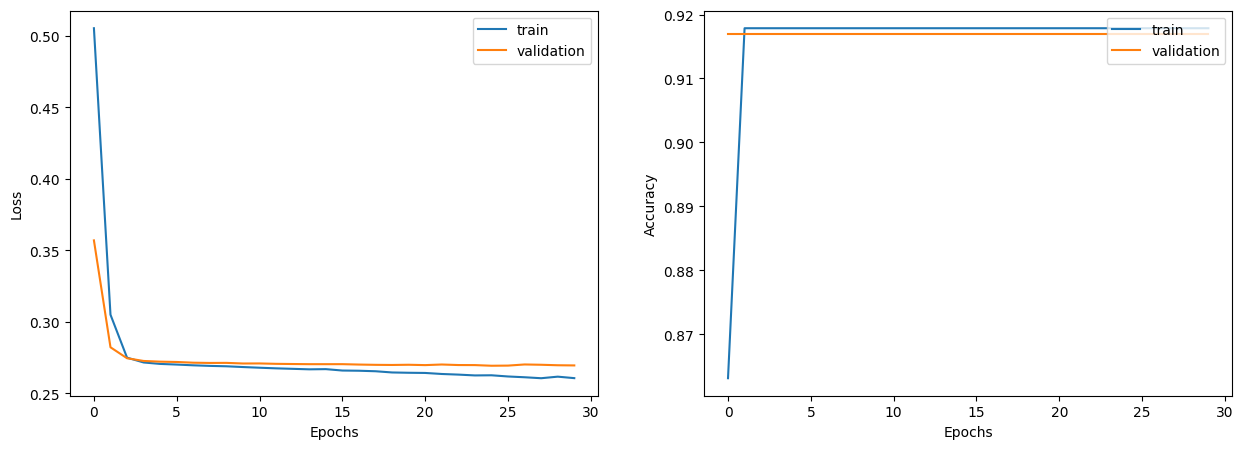

In [ ]:
display_learning_curves(history)

In [ ]:
node2vec_cc

,bert_dim_0,bert_dim_1,bert_dim_2,bert_dim_3,bert_dim_4,bert_dim_5,bert_dim_6,bert_dim_7,bert_dim_8,bert_dim_9,...,bert_dim_120,bert_dim_121,bert_dim_122,bert_dim_123,bert_dim_124,bert_dim_125,bert_dim_126,bert_dim_127,label,Node_id
0,-1.416996,3.080554,0.883337,0.436423,0.312903,-0.342480,0.280378,0.529429,0.012927,-0.416564,...,0.005963,-0.010771,0.175844,-0.182294,-0.168251,-0.098709,0.106996,0.118119,1,0
1,-1.938545,2.263874,0.381174,0.042243,-1.363877,-0.678144,-0.588817,1.265440,0.315046,0.491042,...,0.339523,-0.104740,-0.247963,-0.267406,-0.105029,-0.084752,0.044819,0.191899,2,1
2,0.091383,-2.042176,3.897648,1.959153,-0.314123,1.525755,0.285060,-0.331656,0.313628,0.977599,...,0.222807,-0.174709,-0.115459,-0.353255,-0.490331,-0.132950,-0.431731,-0.392567,1,2
3,-0.618923,-1.249521,-0.298868,-1.988906,-1.755697,-0.538416,0.358814,-1.728714,0.044989,0.667782,...,-0.461830,0.308581,-0.034285,-0.394636,0.327226,-0.397651,0.220092,0.091272,1,3
4,0.032316,0.348407,0.054117,1.618249,-0.744866,0.196870,0.720971,-0.390185,1.085734,-0.694198,...,0.227314,0.000670,0.009874,0.156247,-0.423316,-0.218683,0.173552,0.033033,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2987,-0.368422,-1.685202,-1.407728,0.480114,1.511471,-1.247814,-0.358001,-0.251870,-1.078698,0.278451,...,-0.206852,-0.063152,-0.177376,0.275954,-0.026633,-0.222290,-0.045874,-0.285949,1,2987
2988,0.054089,-0.827499,-0.804193,-0.229900,-1.156991,-0.827191,-0.764800,-0.025063,1.580653,1.691620,...,-0.113234,0.191081,-0.074980,-0.134231,0.032652,-0.092902,-0.381383,0.102739,1,2988
2989,-2.638433,2.506627,0.022427,-0.446583,2.085832,0.664654,-0.443196,0.383287,-0.671918,-0.035079,...,0.197429,-0.426451,-0.017410,-0.194743,0.106819,0.213361,-0.024810,0.057110,2,2989
2990,-2.373600,-0.931012,-1.018898,0.500357,-0.241546,-0.645502,0.300072,-0.815612,-0.676225,-0.159106,...,0.026565,-0.013049,0.275813,-0.001853,0.362640,0.172445,0.130969,-0.143126,1,2990


In [ ]:
import tensorflow as tf

def gcn_model_values(model, data):
    print('Extracting features based on GCN model........')
    # Force the model to run on the CPU to avoid potential GPU issues.
    with tf.device('/CPU:0'):  # Change to '/GPU:0' if you want to use the GPU
        pred = model.predict(data)
    return pred

gcn_train_data = gcn_model_values(gnn_model, x_train)
gcn_val_data = gcn_model_values(gnn_model, x_val)
gcn_test_data = gcn_model_values(gnn_model, x_test)

Extracting features based on GCN model........
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Extracting features based on GCN model........
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Extracting features based on GCN model........
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# create a logistic regression model
model = LogisticRegression()

# fit the model to the training data
model.fit(gcn_train_data, y_train)

# make predictions on the training, testing, and validation data
y_train_pred = model.predict(gcn_train_data)
y_test_pred = model.predict(gcn_test_data)
y_val_pred = model.predict(gcn_val_data)

# evaluate the accuracy of the model on the training, testing, and validation data
Lr_test_accuracy = accuracy_score(y_test, y_test_pred)
Lr_val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Testing accuracy: {Lr_test_accuracy}")
print(f"Validation accuracy: {Lr_val_accuracy}")


Testing accuracy: 0.875
Validation accuracy: 0.8754646840148699


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# initialize the decision tree classifier with the appropriate hyperparameters
max_depth = 10
min_samples_split = 5
model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split)

# train the decision tree classifier on your training data
model.fit(gcn_train_data, y_train)

# evaluate the performance of the decision tree classifier on your validation data
y_pred_val = model.predict(gcn_val_data)
Dt_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Dt_val_accuracy * 100))

# evaluate the performance of the decision tree classifier on your testing data
y_pred_test = model.predict(gcn_test_data)
Dt_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Dt_test_accuracy * 100))


Validation accuracy: 82.34%
Testing accuracy: 82.22%


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define the parameter grid to search
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier()

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(gcn_train_data, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

# Evaluate the best model on the validation data
y_pred_val = best_model.predict(gcn_val_data)
Dt_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy (GridSearchCV): {:.2f}%".format(Dt_val_accuracy * 100))

# Evaluate the best model on the testing data
y_pred_test = best_model.predict(gcn_test_data)
Dt_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy (GridSearchCV): {:.2f}%".format(Dt_test_accuracy * 100))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found:  {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Validation accuracy (GridSearchCV): 87.36%
Testing accuracy (GridSearchCV): 86.94%


In [ ]:
X_train = gcn_train_data
X_val = gcn_val_data
X_test = gcn_test_data

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# initialize the random forest classifier with the appropriate hyperparameters
n_estimators = 100
max_depth = 10
min_samples_split = 5
model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split)

# train the random forest classifier on your training data
model.fit(gcn_train_data, y_train)

# evaluate the performance of the random forest classifier on your validation data
y_pred_val = model.predict(gcn_val_data)
Rf_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Rf_val_accuracy * 100))

# evaluate the performance of the random forest classifier on your testing data
y_pred_test = model.predict(gcn_test_data)
Rf_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Rf_test_accuracy * 100))


Validation accuracy: 87.55%
Testing accuracy: 87.50%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(gcn_train_data, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

# Evaluate the best model on the validation data
y_pred_val = best_model.predict(gcn_val_data)
Rf_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy (GridSearchCV): {:.2f}%".format(Rf_val_accuracy * 100))

# Evaluate the best model on the testing data
y_pred_test = best_model.predict(gcn_test_data)
Rf_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy (GridSearchCV): {:.2f}%".format(Rf_test_accuracy * 100))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Validation accuracy (GridSearchCV): 87.36%
Testing accuracy (GridSearchCV): 87.50%


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# initialize the SVM classifier with the appropriate hyperparameters
C = 1.0
kernel = 'rbf'
gamma = 'scale'
model = SVC(C=C, kernel=kernel, gamma=gamma)

# train the SVM classifier on your training data
model.fit(X_train, y_train)

# evaluate the performance of the SVM classifier on your validation data
y_pred_val = model.predict(X_val)
Svm_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Svm_val_accuracy * 100))

# evaluate the performance of the SVM classifier on your testing data
y_pred_test = model.predict(X_test)
Svm_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Svm_test_accuracy * 100))


Validation accuracy: 87.55%
Testing accuracy: 87.50%


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Initialize the SVM classifier
svm_model = SVC()

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

# Evaluate the best model on the validation data
y_pred_val = best_model.predict(X_val)
Svm_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy (GridSearchCV): {:.2f}%".format(Svm_val_accuracy * 100))

# Evaluate the best model on the testing data
y_pred_test = best_model.predict(X_test)
Svm_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy (GridSearchCV): {:.2f}%".format(Svm_test_accuracy * 100))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found:  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Validation accuracy (GridSearchCV): 87.55%
Testing accuracy (GridSearchCV): 87.50%


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# initialize the AdaBoost classifier with the appropriate hyperparameters
n_estimators = 100
learning_rate = 1.0
algorithm = 'SAMME'
model = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate, algorithm=algorithm)

# train the AdaBoost classifier on your training data
model.fit(X_train, y_train)

# evaluate the performance of the AdaBoost classifier on your validation data
y_pred_val = model.predict(X_val)
Ada_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Ada_val_accuracy * 100))

# evaluate the performance of the AdaBoost classifier on your testing data
y_pred_test = model.predict(X_test)
Ada_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Ada_test_accuracy * 100))


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Validation accuracy: 87.55%
Testing accuracy: 87.50%


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# initialize the Extra Trees classifier with the appropriate hyperparameters
n_estimators = 100
max_depth = None
min_samples_split = 2
random_state = 42
model = ExtraTreesClassifier(n_estimators=n_estimators, max_depth=max_depth,
                             min_samples_split=min_samples_split, random_state=random_state)

# train the Extra Trees classifier on your training data
model.fit(X_train, y_train)

# evaluate the performance of the Extra Trees classifier on your validation data
y_pred_val = model.predict(X_val)
Et_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Et_val_accuracy * 100))

# evaluate the performance of the Extra Trees classifier on your testing data
y_pred_test = model.predict(X_test)
Et_test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing accuracy: {:.2f}%".format(Et_test_accuracy * 100))


Validation accuracy: 86.25%
Testing accuracy: 86.39%


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize the Extra Trees classifier
et_model = ExtraTreesClassifier(random_state=42)

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=et_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

# Evaluate the best model on the validation data
y_pred_val = best_model.predict(X_val)
Et_val_accuracy = accuracy_score(y_val, y_pred_val)
Et_val_precision = precision_score(y_val, y_pred_val, average='weighted')
Et_val_recall = recall_score(y_val, y_pred_val, average='weighted')
Et_val_f1 = f1_score(y_val, y_pred_val, average='weighted')

print("Validation metrics (GridSearchCV):")
print("Accuracy: {:.2f}%".format(Et_val_accuracy * 100))
print("Precision: {:.2f}".format(Et_val_precision))
print("Recall: {:.2f}".format(Et_val_recall))
print("F1 Score: {:.2f}".format(Et_val_f1))

# Evaluate the best model on the testing data
y_pred_test = best_model.predict(X_test)
Et_test_accuracy = accuracy_score(y_test, y_pred_test)
Et_test_precision = precision_score(y_test, y_pred_test, average='weighted')
Et_test_recall = recall_score(y_test, y_pred_test, average='weighted')
Et_test_f1 = f1_score(y_test, y_pred_test, average='weighted')

print("Testing metrics (GridSearchCV):")
print("Accuracy: {:.2f}%".format(Et_test_accuracy * 100))
print("Precision: {:.2f}".format(Et_test_precision))
print("Recall: {:.2f}".format(Et_test_recall))
print("F1 Score: {:.2f}".format(Et_test_f1))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Validation metrics (GridSearchCV):
Accuracy: 87.55%
Precision: 0.77
Recall: 0.88
F1 Score: 0.82
Testing metrics (GridSearchCV):
Accuracy: 87.50%
Precision: 0.77
Recall: 0.88
F1 Score: 0.82


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# initialize the SGD classifier with the appropriate hyperparameters
alpha = 0.0001
max_iter = 1000
tol = 1e-3
model = SGDClassifier(alpha=alpha, max_iter=max_iter, tol=tol)

# train the SGD classifier on your training data
model.fit(X_train, y_train)

# evaluate the performance of the SGD classifier on your validation data
y_pred_val = model.predict(X_val)
Sgd_val_accuracy = accuracy_score(y_val, y_pred_val)
print("Validation accuracy: {:.2f}%".format(Sgd_val_accuracy * 100))

# evaluate the performance of the SGD classifier on your testing data
y_pred_test = model.predict(X_test)
Sgd_test_accuracy = accuracy_score(y_test, y_pred_test)
Sgd_test_recall = recall_score(y_test, y_pred_test, average = 'macro')
Sgd_test_f1_score = f1_score(y_test, y_pred_test, average = 'macro')
print("Testing accuracy: {:.2f}%".format(Sgd_test_accuracy * 100))


Validation accuracy: 87.55%
Testing accuracy: 87.50%


#Scores

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# create a logistic regression model
model = LogisticRegression()

# fit the model to the training data
model.fit(gcn_train_data, y_train)

# make predictions
y_train_pred = model.predict(gcn_train_data)
y_test_pred = model.predict(gcn_test_data)
y_val_pred = model.predict(gcn_val_data)

# evaluate accuracy
Lr_test_accuracy = accuracy_score(y_test, y_test_pred)
Lr_val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Testing accuracy: {Lr_test_accuracy:.4f}")
print(f"Validation accuracy: {Lr_val_accuracy:.4f}")

# macro, micro, and weighted metrics for test set
for avg in ['macro', 'micro', 'weighted']:
    print(f"\n--- {avg.upper()} ---")
    print(f"Precision: {precision_score(y_test, y_test_pred, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_test_pred, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_test_pred, average=avg):.4f}")


Testing accuracy: 0.8750
Validation accuracy: 0.8755

--- MACRO ---
Precision: 0.2917
Recall:    0.3333
F1-score:  0.3111

--- MICRO ---
Precision: 0.8750
Recall:    0.8750
F1-score:  0.8750

--- WEIGHTED ---
Precision: 0.7656
Recall:    0.8750
F1-score:  0.8167


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define the parameter grid to search
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier()

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(gcn_train_data, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

# Evaluate on validation data
y_pred_val = best_model.predict(gcn_val_data)
Dt_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Dt_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

# Evaluate on test data
y_pred_test = best_model.predict(gcn_test_data)
Dt_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Dt_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")



Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found:  {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}

Validation accuracy: 0.8736

Validation (MACRO):
Precision: 0.2917
Recall:    0.3326
F1-score:  0.3108

Validation (MICRO):
Precision: 0.8736
Recall:    0.8736
F1-score:  0.8736

Validation (WEIGHTED):
Precision: 0.7662
Recall:    0.8736
F1-score:  0.8164

Testing accuracy: 0.8694

Testing (MACRO):
Precision: 0.3755
Recall:    0.3387
F1-score:  0.3255

Testing (MICRO):
Precision: 0.8694
Recall:    0.8694
F1-score:  0.8694

Testing (WEIGHTED):
Precision: 0.7939
Recall:    0.8694
F1-score:  0.8187


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Initialize the SVM classifier
svm_model = SVC()

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5,
                           scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

# ---------- Validation evaluation ----------
y_pred_val = best_model.predict(X_val)
Svm_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Svm_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

# ---------- Testing evaluation ----------
y_pred_test = best_model.predict(X_test)
Svm_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Svm_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")



Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found:  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Validation accuracy: 0.8755

Validation (MACRO):
Precision: 0.2918
Recall:    0.3333
F1-score:  0.3112

Validation (MICRO):
Precision: 0.8755
Recall:    0.8755
F1-score:  0.8755

Validation (WEIGHTED):
Precision: 0.7664
Recall:    0.8755
F1-score:  0.8173

Testing accuracy: 0.8750

Testing (MACRO):
Precision: 0.2917
Recall:    0.3333
F1-score:  0.3111

Testing (MICRO):
Precision: 0.8750
Recall:    0.8750
F1-score:  0.8750

Testing (WEIGHTED):
Precision: 0.7656
Recall:    0.8750
F1-score:  0.8167


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize the Extra Trees classifier
et_model = ExtraTreesClassifier(random_state=42)

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=et_model, param_grid=param_grid, cv=5,
                           scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

# ---- Function to print metrics for any split ----
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} metrics (GridSearchCV):")
    print("Accuracy: {:.2f}%".format(accuracy_score(y_true, y_pred) * 100))

    # Weighted
    print("Precision (weighted): {:.4f}".format(precision_score(y_true, y_pred, average='weighted')))
    print("Recall (weighted): {:.4f}".format(recall_score(y_true, y_pred, average='weighted')))
    print("F1 Score (weighted): {:.4f}".format(f1_score(y_true, y_pred, average='weighted')))

    # Macro
    print("Precision (macro): {:.4f}".format(precision_score(y_true, y_pred, average='macro')))
    print("Recall (macro): {:.4f}".format(recall_score(y_true, y_pred, average='macro')))
    print("F1 Score (macro): {:.4f}".format(f1_score(y_true, y_pred, average='macro')))

    # Micro
    print("Precision (micro): {:.4f}".format(precision_score(y_true, y_pred, average='micro')))
    print("Recall (micro): {:.4f}".format(recall_score(y_true, y_pred, average='micro')))
    print("F1 Score (micro): {:.4f}".format(f1_score(y_true, y_pred, average='micro')))

# Evaluate on validation data
evaluate_model("Validation", y_val, best_model.predict(X_val))

# Evaluate on testing data
evaluate_model("Testing", y_test, best_model.predict(X_test))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}

Validation metrics (GridSearchCV):
Accuracy: 87.55%
Precision (weighted): 0.7664
Recall (weighted): 0.8755
F1 Score (weighted): 0.8173
Precision (macro): 0.2918
Recall (macro): 0.3333
F1 Score (macro): 0.3112
Precision (micro): 0.8755
Recall (micro): 0.8755
F1 Score (micro): 0.8755

Testing metrics (GridSearchCV):
Accuracy: 87.50%
Precision (weighted): 0.7656
Recall (weighted): 0.8750
F1 Score (weighted): 0.8167
Precision (macro): 0.2917
Recall (macro): 0.3333
F1 Score (macro): 0.3111
Precision (micro): 0.8750
Recall (micro): 0.8750
F1 Score (micro): 0.8750


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize the AdaBoost classifier
n_estimators = 100
learning_rate = 1.0
algorithm = 'SAMME'
model = AdaBoostClassifier(n_estimators=n_estimators,
                           learning_rate=learning_rate,
                           algorithm=algorithm)

# Train the AdaBoost classifier
model.fit(X_train, y_train)

# ---------- Validation evaluation ----------
y_pred_val = model.predict(X_val)
Ada_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Ada_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

# ---------- Testing evaluation ----------
y_pred_test = model.predict(X_test)
Ada_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Ada_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



Validation accuracy: 0.8755

Validation (MACRO):
Precision: 0.2918
Recall:    0.3333
F1-score:  0.3112

Validation (MICRO):
Precision: 0.8755
Recall:    0.8755
F1-score:  0.8755

Validation (WEIGHTED):
Precision: 0.7664
Recall:    0.8755
F1-score:  0.8173

Testing accuracy: 0.8750

Testing (MACRO):
Precision: 0.2917
Recall:    0.3333
F1-score:  0.3111

Testing (MICRO):
Precision: 0.8750
Recall:    0.8750
F1-score:  0.8750

Testing (WEIGHTED):
Precision: 0.7656
Recall:    0.8750
F1-score:  0.8167


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(gcn_train_data, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best parameters found: ", best_params)

# ---------- Validation evaluation ----------
y_pred_val = best_model.predict(gcn_val_data)
Rf_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Rf_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

# ---------- Testing evaluation ----------
y_pred_test = best_model.predict(gcn_test_data)
Rf_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Rf_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}

Validation accuracy: 0.8736

Validation (MACRO):
Precision: 0.2917
Recall:    0.3326
F1-score:  0.3108

Validation (MICRO):
Precision: 0.8736
Recall:    0.8736
F1-score:  0.8736

Validation (WEIGHTED):
Precision: 0.7662
Recall:    0.8736
F1-score:  0.8164

Testing accuracy: 0.8750

Testing (MACRO):
Precision: 0.2917
Recall:    0.3333
F1-score:  0.3111

Testing (MICRO):
Precision: 0.8750
Recall:    0.8750
F1-score:  0.8750

Testing (WEIGHTED):
Precision: 0.7656
Recall:    0.8750
F1-score:  0.8167


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize the SGD classifier
alpha = 0.0001
max_iter = 1000
tol = 1e-3
model = SGDClassifier(alpha=alpha, max_iter=max_iter, tol=tol)

# Train the SGD classifier
model.fit(X_train, y_train)

# ---------- Validation evaluation ----------
y_pred_val = model.predict(X_val)
Sgd_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {Sgd_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

# ---------- Testing evaluation ----------
y_pred_test = model.predict(X_test)
Sgd_test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTesting accuracy: {Sgd_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_test, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred_test, average=avg):.4f}")



Validation accuracy: 0.8755

Validation (MACRO):
Precision: 0.2918
Recall:    0.3333
F1-score:  0.3112

Validation (MICRO):
Precision: 0.8755
Recall:    0.8755
F1-score:  0.8755

Validation (WEIGHTED):
Precision: 0.7664
Recall:    0.8755
F1-score:  0.8173

Testing accuracy: 0.8750

Testing (MACRO):
Precision: 0.2917
Recall:    0.3333
F1-score:  0.3111

Testing (MICRO):
Precision: 0.8750
Recall:    0.8750
F1-score:  0.8750

Testing (WEIGHTED):
Precision: 0.7656
Recall:    0.8750
F1-score:  0.8167


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

# Initialize the base models
lr_model = LogisticRegression(max_iter=1000)
# Change the loss to 'log_loss' for probability estimates
sgd_model = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3)

# Create the Voting Classifier (change voting='hard' for hard voting)
vc_model = VotingClassifier(
    estimators=[('lr', lr_model), ('sgd', sgd_model)],
    voting='soft'  # use 'hard' for majority voting
)

# Train the voting classifier
vc_model.fit(X_train, y_train)

# ---------- Validation evaluation ----------
y_pred_val = vc_model.predict(X_val)
vc_val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\nValidation accuracy: {vc_val_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nValidation ({avg.upper()}):")
    print(f"Precision: {precision_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_val, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_val, average=avg):.4f}")

# ---------- Testing evaluation ----------
y_pred_test = vc_model.predict(X_test)
vc_test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTesting accuracy: {vc_test_accuracy:.4f}")
for avg in ['macro', 'micro', 'weighted']:
    print(f"\nTesting ({avg.upper()}):")
    print(f"Precision: {precision_score(y_test, y_test_pred, average=avg):.4f}")
    print(f"Recall:    {recall_score(y_test, y_test_pred, average=avg):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_test_pred, average=avg):.4f}")


Validation accuracy: 0.8755

Validation (MACRO):
Precision: 0.2918
Recall:    0.3333
F1-score:  0.3112

Validation (MICRO):
Precision: 0.8755
Recall:    0.8755
F1-score:  0.8755

Validation (WEIGHTED):
Precision: 0.7664
Recall:    0.8755
F1-score:  0.8173

Testing accuracy: 0.8750

Testing (MACRO):
Precision: 0.2917
Recall:    0.3333
F1-score:  0.3111

Testing (MICRO):
Precision: 0.8750
Recall:    0.8750
F1-score:  0.8750

Testing (WEIGHTED):
Precision: 0.7656
Recall:    0.8750
F1-score:  0.8167


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m